# **Baseline Model: SVM (Support Vector Machine)**

**Project:** Multilingual Classification of Urgent Disaster Response Messages  
**Input:** `humaid_processed.csv` (from Notebook 01)

This notebook:
1. Loads processed data
2. TF-IDF vectorization
3. Trains LinearSVC with balanced class weights
4. Evaluation: classification report, confusion matrix, per-class recall
5. Error analysis: dangerous false negatives

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

print("All imports successful!")

All imports successful!


## 1. Configuration and Data Loading

In [20]:
BASE_DIR = r"C:\Users\muham\Documents\Acads\Sem 6\NLP\Project\Multilingual-Classification-of-Urgent-Disaster-Response-Messages"

PROCESSED_CSV = os.path.join(BASE_DIR, "datasets", "processed", "humaid_processed.csv")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

PLOTS_DIR = {
    "svm":  os.path.join(RESULTS_DIR, "plots", "svm"),
    "nb":   os.path.join(RESULTS_DIR, "plots", "naive_bayes"),
    "lr":   os.path.join(RESULTS_DIR, "plots", "logistic_regression")
}

CLASS_ORDER = [
    "Critical Rescue",
    "Resource Requests",
    "Volunteering and Donations",
    "Situational Awareness",
    "Irrelevant",
]

CLASS_COLORS = {
    "Critical Rescue":             "#d32f2f",
    "Resource Requests":           "#ff9800",
    "Volunteering and Donations":  "#4caf50",
    "Situational Awareness":       "#2196f3",
    "Irrelevant":                  "#9e9e9e",
}

df = pd.read_csv(PROCESSED_CSV)
print(f"Loaded {len(df)} rows")
print(f"Columns: {list(df.columns)}")
print(f"\nClass distribution:")
print(df["target_label"].value_counts().reindex(CLASS_ORDER))

Loaded 74227 rows
Columns: ['tweet_id', 'tweet_text', 'class_label', 'event', 'split', 'event_set', 'target_label', 'clean_text', 'text_length', 'word_count']

Class distribution:
target_label
Critical Rescue               10949
Resource Requests              2593
Volunteering and Donations    20849
Situational Awareness         25192
Irrelevant                    14644
Name: count, dtype: int64


In [21]:
for folder in PLOTS_DIR.values():
    os.makedirs(folder, exist_ok=True)

In [22]:
df = pd.read_csv(PROCESSED_CSV)
print(f"Loaded {len(df)} rows")
print(f"\nClass distribution:")
print(df["target_label"].value_counts().reindex(CLASS_ORDER))

Loaded 74227 rows

Class distribution:
target_label
Critical Rescue               10949
Resource Requests              2593
Volunteering and Donations    20849
Situational Awareness         25192
Irrelevant                    14644
Name: count, dtype: int64


## 2. Train / Test Split

Using HumAID's built-in splits.

In [23]:
train_df = df[df["split"] == "train"].copy()
dev_df   = df[df["split"] == "dev"].copy()
test_df  = df[df["split"] == "test"].copy()

print(f"Train: {len(train_df)}")
print(f"Dev:   {len(dev_df)}")
print(f"Test:  {len(test_df)}")

Train: 51952
Dev:   7564
Test:  14711


In [24]:
print(f"\nTrain class distribution:")
print(train_df["target_label"].value_counts().reindex(CLASS_ORDER))
print(f"\nTest class distribution:")
print(test_df["target_label"].value_counts().reindex(CLASS_ORDER))


Train class distribution:
target_label
Critical Rescue                7663
Resource Requests              1815
Volunteering and Donations    14591
Situational Awareness         17634
Irrelevant                    10249
Name: count, dtype: int64

Test class distribution:
target_label
Critical Rescue               2167
Resource Requests              516
Volunteering and Donations    4133
Situational Awareness         4993
Irrelevant                    2902
Name: count, dtype: int64


## 3. TF-IDF Vectorization

Using unigrams + bigrams with sublinear TF scaling and max 30,000 features.

In [25]:
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
)

X_train = tfidf.fit_transform(train_df["clean_text"])
X_test  = tfidf.transform(test_df["clean_text"])
y_train = train_df["target_label"]
y_test  = test_df["target_label"]

print(f"TF-IDF vocabulary size: {len(tfidf.vocabulary_)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

TF-IDF vocabulary size: 30000
X_train shape: (51952, 30000)
X_test shape:  (14711, 30000)


## 4. Train SVM

Using `LinearSVC` with `class_weight='balanced'` to handle class imbalance. This automatically upweights minority classes (especially Resource Requests at 3.4%) inversely proportional to their frequency.

In [26]:
svm = LinearSVC(
    class_weight="balanced",
    C=1.0,
    max_iter=5000,
)

print("Training SVM...")
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
print("Training complete!")

Training SVM...
Training complete!


## 5. Evaluation

### 5.1 Classification Report

In [27]:
print(classification_report(
    y_test, y_pred,
    target_names=CLASS_ORDER,
    labels=CLASS_ORDER,
    zero_division=0,
))

                            precision    recall  f1-score   support

           Critical Rescue       0.88      0.91      0.90      2167
         Resource Requests       0.52      0.54      0.53       516
Volunteering and Donations       0.83      0.85      0.84      4133
     Situational Awareness       0.81      0.80      0.80      4993
                Irrelevant       0.72      0.68      0.70      2902

                  accuracy                           0.80     14711
                 macro avg       0.75      0.76      0.75     14711
              weighted avg       0.80      0.80      0.80     14711



### 5.2 Confusion Matrix

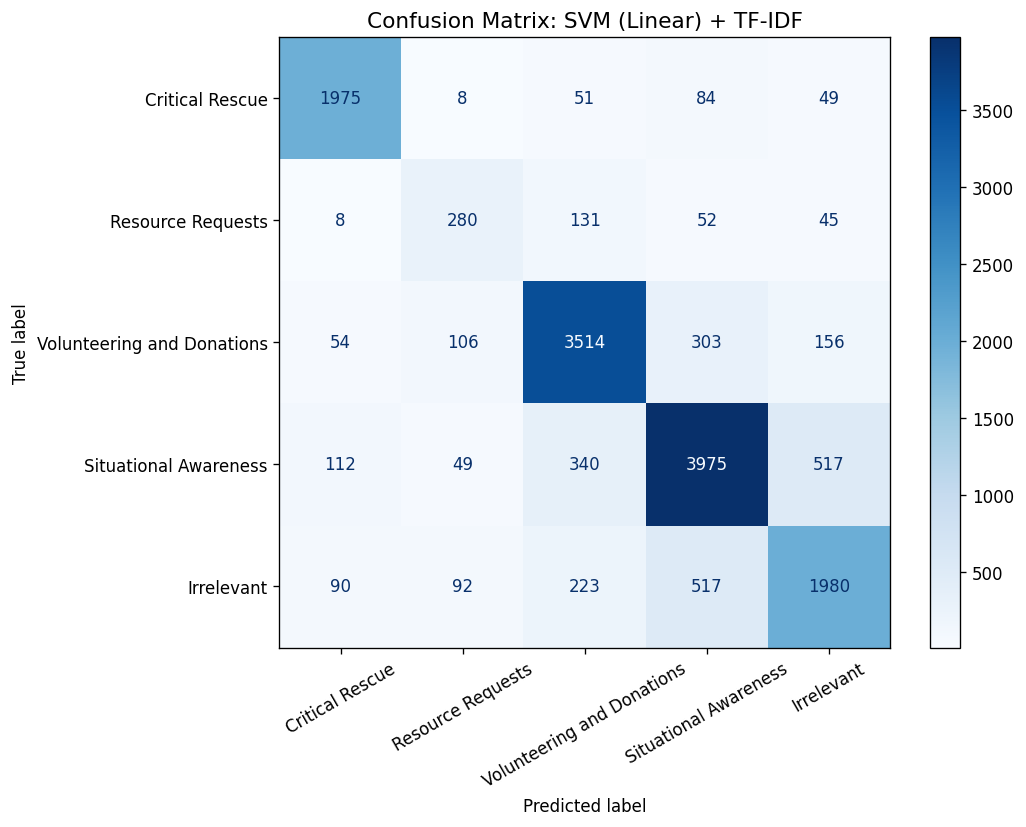

In [28]:
cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=30)
ax.set_title("Confusion Matrix: SVM (Linear) + TF-IDF", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR["svm"], "cm_svm.png"), dpi=150, bbox_inches="tight")
plt.show()

### 5.3 Per-Class Recall

Recall is the priority metric — in disaster response, missing an urgent message is far worse than a false alarm.

In [29]:
report_dict = classification_report(
    y_test, y_pred,
    target_names=CLASS_ORDER,
    labels=CLASS_ORDER,
    output_dict=True,
    zero_division=0,
)

print(f"{'Class':30s}  {'Precision':>9s}  {'Recall':>6s}  {'F1':>6s}  {'Support':>7s}")
print("-" * 65)
for cls in CLASS_ORDER:
    r = report_dict[cls]
    print(f"{cls:30s}  {r['precision']:9.3f}  {r['recall']:6.3f}  {r['f1-score']:6.3f}  {int(r['support']):7d}")
print("-" * 65)
print(f"{'Macro Avg':30s}  {report_dict['macro avg']['precision']:9.3f}  "
      f"{report_dict['macro avg']['recall']:6.3f}  {report_dict['macro avg']['f1-score']:6.3f}")
print(f"{'Weighted Avg':30s}  {report_dict['weighted avg']['precision']:9.3f}  "
      f"{report_dict['weighted avg']['recall']:6.3f}  {report_dict['weighted avg']['f1-score']:6.3f}")

Class                           Precision  Recall      F1  Support
-----------------------------------------------------------------
Critical Rescue                     0.882   0.911   0.897     2167
Resource Requests                   0.523   0.543   0.533      516
Volunteering and Donations          0.825   0.850   0.837     4133
Situational Awareness               0.806   0.796   0.801     4993
Irrelevant                          0.721   0.682   0.701     2902
-----------------------------------------------------------------
Macro Avg                           0.751   0.757   0.754
Weighted Avg                        0.796   0.797   0.796


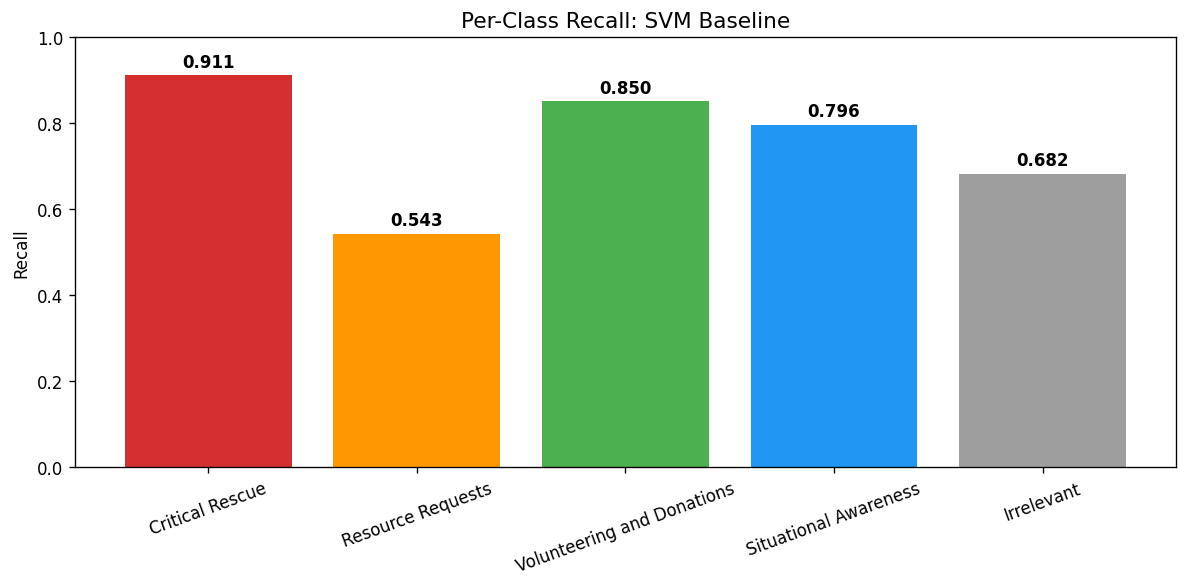

In [30]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
recalls = [report_dict[c]["recall"] for c in CLASS_ORDER]
bar_colors = [CLASS_COLORS[c] for c in CLASS_ORDER]
ax.bar(CLASS_ORDER, recalls, color=bar_colors)
ax.set_ylabel("Recall")
ax.set_title("Per-Class Recall: SVM Baseline", fontsize=13)
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=20)
for i, r in enumerate(recalls):
    ax.text(i, r + 0.02, f"{r:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR["svm"], "recall_svm.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. Error Analysis

### 6.1 Dangerous False Negatives

Urgent messages (Critical Rescue / Resource Requests) misclassified as non-urgent (Situational Awareness / Irrelevant). These are the most costly errors in a disaster response system.

In [31]:
test_analysis = test_df.copy()
test_analysis["pred_label"] = y_pred
test_analysis["correct"] = y_test.values == y_pred

urgent = ["Critical Rescue", "Resource Requests"]
non_urgent = ["Situational Awareness", "Irrelevant"]

dangerous_fn = test_analysis[
    (test_analysis["target_label"].isin(urgent)) &
    (test_analysis["pred_label"].isin(non_urgent))
]

total_urgent = len(test_analysis[test_analysis["target_label"].isin(urgent)])
print(f"Total urgent messages in test set: {total_urgent}")
print(f"Dangerous false negatives: {len(dangerous_fn)} ({len(dangerous_fn)/total_urgent*100:.1f}% of urgent messages)")
print(f"  Critical Rescue → non-urgent:   "
      f"{len(dangerous_fn[dangerous_fn['target_label']=='Critical Rescue'])}")
print(f"  Resource Requests → non-urgent:  "
      f"{len(dangerous_fn[dangerous_fn['target_label']=='Resource Requests'])}")

Total urgent messages in test set: 2683
Dangerous false negatives: 230 (8.6% of urgent messages)
  Critical Rescue → non-urgent:   133
  Resource Requests → non-urgent:  97


In [32]:
print(f"\nExamples:")
print("-" * 70)
for _, row in dangerous_fn.head(8).iterrows():
    print(f"  TRUE: {row['target_label']}  →  PRED: {row['pred_label']}")
    print(f"  TEXT: {row['tweet_text'][:140]}")
    print()


Examples:
----------------------------------------------------------------------
  TRUE: Critical Rescue  →  PRED: Situational Awareness
  TEXT: RT @marcmack: Devastating wildfire in Fort McMurray, northern Alberta: 80000 evacuated, 1600 homes destroyed. Text REDCROSS to 30333 &amp; d

  TRUE: Critical Rescue  →  PRED: Situational Awareness
  TEXT: @RMWoodBuffalo do you want residents to update their location status at wildfire@rmwb.ca once they relocate from camps north of YMM?

  TRUE: Critical Rescue  →  PRED: Situational Awareness
  TEXT: RT @RobKIRO7: Next at 630 on @KIRO7Seattle - latest on wildfire near Gold Bar. Still about 100 homes may be evacd as 12 have already been.

  TRUE: Critical Rescue  →  PRED: Situational Awareness
  TEXT: CANADA ALBERTA: #FortMacFire damage: oil firms plan restart: 88K evacuees; 2400 buildings destroyed; #WTP operating

  TRUE: Critical Rescue  →  PRED: Irrelevant
  TEXT: Fort McMurray video shows evacuee’s terrifying wildfire escape  via @toronto

### 6.2 Critical Rescue ↔ Resource Requests Confusion

In [33]:
rescue_as_resource = test_analysis[
    (test_analysis["target_label"] == "Critical Rescue") &
    (test_analysis["pred_label"] == "Resource Requests")
]
resource_as_rescue = test_analysis[
    (test_analysis["target_label"] == "Resource Requests") &
    (test_analysis["pred_label"] == "Critical Rescue")
]

In [34]:
print(f"Critical Rescue → Resource Requests: {len(rescue_as_resource)}")
print(f"Resource Requests → Critical Rescue: {len(resource_as_rescue)}")

print(f"\nCritical Rescue misclassified as Resource Requests:")
for _, row in rescue_as_resource.head(5).iterrows():
    print(f"  > {row['tweet_text'][:140]}")
    print()

print(f"Resource Requests misclassified as Critical Rescue:")
for _, row in resource_as_rescue.head(5).iterrows():
    print(f"  > {row['tweet_text'][:140]}")
    print()

Critical Rescue → Resource Requests: 8
Resource Requests → Critical Rescue: 8

Critical Rescue misclassified as Resource Requests:
  > #CycloneIdai has killed hundreds and affected millions in #Mozambique, #Malawi &amp; #Zimbabwe. CARE is joining @decappeal members in launch

  > Burger Stadium in Austin now open as evacuee center. Urgent need: diapers, sanitary products, clothing, shoes. No food. Drop off at entrance

  > #unnecessary #deaths #PortoRico Airdrops of food, water &amp; medicine urgent. Trump should be in Sit Room @ WH-not golfing in New Jersey

  > RT @johnpaulfarmer: 2/ People are dying right now. Communication is impossible for many. Food &amp; even potable water are scarce in places.

  > California is a horrible mess right now with citizens struggling due to the fires. I know, because I am one of them. No home. Not clothes. N

Resource Requests misclassified as Critical Rescue:
  > A huge number of people have been displaced and need food, shelter and health faciliti

### 6.3 Per-Class Accuracy

In [35]:
print(f"{'Class':30s}  {'Accuracy':>8s}  {'Correct':>7s}  {'Total':>5s}")
print("-" * 55)
for label in CLASS_ORDER:
    subset = test_analysis[test_analysis["target_label"] == label]
    if len(subset) > 0:
        acc = subset["correct"].mean()
        print(f"{label:30s}  {acc:8.3f}  {subset['correct'].sum():7d}  {len(subset):5d}")

Class                           Accuracy  Correct  Total
-------------------------------------------------------
Critical Rescue                    0.911     1975   2167
Resource Requests                  0.543      280    516
Volunteering and Donations         0.850     3514   4133
Situational Awareness              0.796     3975   4993
Irrelevant                         0.682     1980   2902


## 7. Save Results

In [36]:
# Save all misclassifications for manual review
errors = test_analysis[~test_analysis["correct"]].sort_values("target_label")
errors.to_csv(os.path.join(BASE_DIR, "results", "svm_errors.csv"), index=False)
print(f"Saved {len(errors)} misclassified samples to results/svm_errors.csv")

# Save report dict for model comparison later
import json
results_path = os.path.join(BASE_DIR, "results", "svm_results.json")
with open(results_path, "w") as f:
    json.dump(report_dict, f, indent=2)
print(f"Saved classification report to {results_path}")

print(f"\nSVM Baseline Summary:")
print(f"  Macro F1:    {report_dict['macro avg']['f1-score']:.3f}")
print(f"  Weighted F1: {report_dict['weighted avg']['f1-score']:.3f}")

Saved 2987 misclassified samples to results/svm_errors.csv
Saved classification report to C:\Users\muham\Documents\Acads\Sem 6\NLP\Project\Multilingual-Classification-of-Urgent-Disaster-Response-Messages\results\svm_results.json

SVM Baseline Summary:
  Macro F1:    0.754
  Weighted F1: 0.796
